# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [1]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("ravenstack_feature_usage.csv")

print("subscriptions 크기:", subscriptions.shape)
print(subscriptions.head())

print("feature_usage 크기:", feature_usage.shape)
print(feature_usage.head())

subscription_cols = [
    "subscription_id",
    "start_date",
    "end_date"
]

usage_cols = [
    "usage_id",
    "subscription_id",
    "usage_date"
]

print(subscriptions[subscription_cols].dtypes)
print(subscriptions[subscription_cols].isna().sum())

print(feature_usage[usage_cols].dtypes)
print(feature_usage[usage_cols].isna().sum())

subscriptions["start_date"] = pd.to_datetime(
    subscriptions["start_date"]
)

subscriptions["end_date"] = pd.to_datetime(
    subscriptions["end_date"]
)

feature_usage["usage_date"] = pd.to_datetime(
    feature_usage["usage_date"]
)

usage_with_sub = feature_usage.merge(
    subscriptions[
        [
            "subscription_id",
            "start_date",
            "end_date"
        ]
    ],
    on="subscription_id",
    how="left"
)

before_start_count = (
    usage_with_sub["usage_date"]
    < usage_with_sub["start_date"]
).sum()

after_end_count = (
    usage_with_sub["end_date"].notna()
    & (
        usage_with_sub["usage_date"]
        > usage_with_sub["end_date"]
    )
).sum()

print("구독 시작 전 사용 기록:", before_start_count)
print("구독 종료 후 사용 기록:", after_end_count)

valid_usage = usage_with_sub[
    (usage_with_sub["usage_date"] >= usage_with_sub["start_date"])
    & (
        usage_with_sub["end_date"].isna()
        | (
            usage_with_sub["usage_date"]
            <= usage_with_sub["end_date"]
        )
    )
].copy()

print("유효 기능 사용 기록 수:", len(valid_usage))
print(valid_usage.head())

subscriptions 크기: (5000, 14)
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   
3        S-f81687   A-e7a1e2  2024-11-23  2024-12-13  Enterprise      5   
4        S-cff5a2   A-ba6516  2024-01-10         NaN  Enterprise     27   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0      True          True           False       False   
3         995       11940     False         False           False        True   
4        5373       64476     False         False           False       False   

  billing_frequency  auto_renew_f

---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?

#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

        Month 0 Month 1 Month 2 Month 3 Month 4 Month 5 Month 6
2024-01  100.0%   15.1%   16.4%   19.2%   20.5%   16.4%   19.2%
2024-02  100.0%   21.3%   16.9%   15.7%    7.9%   23.6%   28.1%
2024-03  100.0%   22.4%   22.4%   20.6%   19.6%   10.3%   21.5%
2024-04  100.0%   17.9%   27.4%   19.8%   19.8%   16.0%   15.1%
2024-05  100.0%   18.2%   19.7%   16.8%   21.2%   19.7%   15.3%
2024-06  100.0%   28.0%   12.0%   16.0%   20.0%   15.3%   21.3%


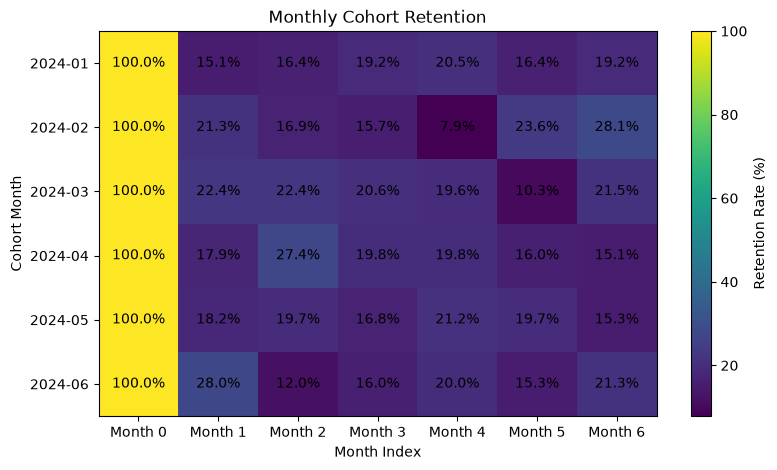

Month 1 리텐션이 가장 높은 코호트
코호트: 2024-06
리텐션: 28.00%

Month 1 리텐션이 가장 낮은 코호트
코호트: 2024-01
리텐션: 15.07%


In [2]:
# 필수 1 코드를 작성하세요.
valid_usage["activity_month"] = (
    valid_usage["usage_date"]
    .dt.to_period("M")
)

first_activity = (
    valid_usage
    .groupby("subscription_id")["activity_month"]
    .min()
    .rename("cohort_month")
)

valid_usage = valid_usage.merge(
    first_activity,
    on="subscription_id",
    how="left"
)

valid_usage["month_index"] = (
    (valid_usage["activity_month"].dt.year - valid_usage["cohort_month"].dt.year) * 12
    + (valid_usage["activity_month"].dt.month - valid_usage["cohort_month"].dt.month)
)

cohort_sizes = (
    valid_usage
    .groupby("cohort_month")["subscription_id"]
    .nunique()
)

cohort_counts = (
    valid_usage
    .groupby(["cohort_month", "month_index"])["subscription_id"]
    .nunique()
    .unstack(fill_value=0)
)

retention_table = cohort_counts.div(
    cohort_sizes,
    axis=0
)

selected_cohorts = pd.period_range(
    "2024-01",
    "2024-06",
    freq="M"
)

selected_retention = (
    retention_table
    .reindex(
        index=selected_cohorts,
        columns=range(7)
    )
)

percent_table = selected_retention.map(
    lambda x: f"{x * 100:.1f}%" if pd.notna(x) else "-"
)

percent_table.index = percent_table.index.astype(str)
percent_table.columns = [
    f"Month {i}" for i in range(7)
]

print(percent_table)


heatmap_data = selected_retention * 100

fig, ax = plt.subplots(figsize=(9, 5))

image = ax.imshow(
    heatmap_data,
    aspect="auto"
)

ax.set_xticks(range(7))
ax.set_xticklabels(
    [f"Month {i}" for i in range(7)]
)

ax.set_yticks(range(len(selected_cohorts)))
ax.set_yticklabels(
    [str(cohort) for cohort in selected_cohorts]
)

ax.set_xlabel("Month Index")
ax.set_ylabel("Cohort Month")
ax.set_title("Monthly Cohort Retention")

for i in range(len(selected_cohorts)):
    for j in range(7):
        value = heatmap_data.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center"
            )

plt.colorbar(
    image,
    ax=ax,
    label="Retention Rate (%)"
)

plt.show()


month1_retention = selected_retention[1].dropna()

highest_cohort = month1_retention.idxmax()
lowest_cohort = month1_retention.idxmin()

highest_rate = month1_retention.max()
lowest_rate = month1_retention.min()

print("Month 1 리텐션이 가장 높은 코호트")
print("코호트:", highest_cohort)
print(f"리텐션: {highest_rate * 100:.2f}%")

print("\nMonth 1 리텐션이 가장 낮은 코호트")
print("코호트:", lowest_cohort)
print(f"리텐션: {lowest_rate * 100:.2f}%")

### 필수 1 답변 작성란

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?
  - 분석 목적이 제품의 핵심 기능을 처음 사용한 뒤 다시 사용하는지를 확인하는 것이기 때문
  - 실제 가치 경험의 시작점을 비교할 수 있음

**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?
  - 각 구독을 첫 기능 사용 월에 배정했으므로 코호트에 포함된 모든 구독이 Month 0에서는 기능을 사용함

**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?
  - 가장 높은 코호트는 2024년 6월(28%)
  - 가장 낮은 코호트는 2024년 1월(15%)

**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?
  - 있다. 각 월에 기능을 사용했는지 따로 계산하기 때문에 한 달 쉬었다가 다음 달에 돌아온 구독이 있으면 리텐션이 N개월 뒤에서도 높아질 수 있다.

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  
**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

            코호트 구독 수  Month 1 재사용 구독 수 Month 1 리텐션
plan_tier                                         
Basic            223                42      18.83%
Pro              219                48      21.92%
Enterprise       220                50      22.73%


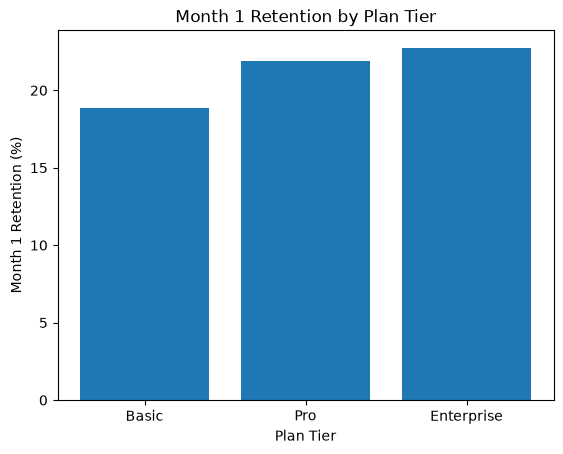


Month 1 리텐션이 가장 낮은 요금제
요금제: Basic
리텐션: 18.83%

개선 방향
Basic 요금제 사용자가 첫 기능 사용 이후 다시 제품을 사용할 동기가 부족할 가능성이 있으므로 초기 사용 경험과 핵심 기능 안내를 강화하는 방안을 검토할 수 있다.

추가 확인 데이터
기능별 사용 빈도, 첫 사용 이후 재방문 간격, 구독 기간, 계정 규모와 같은 데이터를 추가로 확인할 수 있다.


In [3]:
# 필수 2 코드를 작성하세요.
cohort_base = (
    valid_usage[
        ["subscription_id", "cohort_month"]
    ]
    .drop_duplicates()
    .merge(
        subscriptions[
            ["subscription_id", "plan_tier"]
        ],
        on="subscription_id",
        how="left"
    )
)

selected_base = cohort_base[
    cohort_base["cohort_month"].between(
        pd.Period("2024-01", freq="M"),
        pd.Period("2024-06", freq="M")
    )
].copy()

plan_cohort_size = (
    selected_base
    .groupby("plan_tier")["subscription_id"]
    .nunique()
)

month1_usage = (
    valid_usage[
        valid_usage["month_index"] == 1
    ][["subscription_id"]]
    .drop_duplicates()
    .merge(
        selected_base[
            ["subscription_id", "plan_tier"]
        ],
        on="subscription_id",
        how="inner"
    )
)

plan_month1_count = (
    month1_usage
    .groupby("plan_tier")["subscription_id"]
    .nunique()
)

plan_retention = pd.DataFrame({
    "코호트 구독 수": plan_cohort_size,
    "Month 1 재사용 구독 수": plan_month1_count
}).fillna(0)

plan_retention["Month 1 리텐션"] = (
    plan_retention["Month 1 재사용 구독 수"]
    / plan_retention["코호트 구독 수"]
)

plan_retention = plan_retention.sort_values(
    "Month 1 리텐션"
)

plan_retention_print = plan_retention.copy()

plan_retention_print["Month 1 리텐션"] = (
    plan_retention_print["Month 1 리텐션"]
    .apply(lambda x: f"{x * 100:.2f}%")
)

print(plan_retention_print)

plt.bar(
    plan_retention.index,
    plan_retention["Month 1 리텐션"] * 100
)

plt.xlabel("Plan Tier")
plt.ylabel("Month 1 Retention (%)")
plt.title("Month 1 Retention by Plan Tier")
plt.show()

lowest_plan = plan_retention["Month 1 리텐션"].idxmin()
lowest_rate = plan_retention["Month 1 리텐션"].min()

print("\nMonth 1 리텐션이 가장 낮은 요금제")
print("요금제:", lowest_plan)
print(f"리텐션: {lowest_rate * 100:.2f}%")

print("\n개선 방향")
print(
    f"{lowest_plan} 요금제 사용자가 첫 기능 사용 이후 다시 제품을 사용할 "
    "동기가 부족할 가능성이 있으므로 초기 사용 경험과 핵심 기능 안내를 "
    "강화하는 방안을 검토할 수 있다."
)

print("\n추가 확인 데이터")
print(
    "기능별 사용 빈도, 첫 사용 이후 재방문 간격, 구독 기간, "
    "계정 규모와 같은 데이터를 추가로 확인할 수 있다."
)

### 필수 2 답변 작성란

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  
  - 고객의 계약 요금제라는 특성을 기준으로 나누었다.(속성 기반 세그멘테이션)

**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요? 
  - Basic이며 약 18.8% 정도

**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?
  - 전체 평균에 가려진 낮은 요금제 그룹을 찾아 개선 대상을 더 구체적으로 정할 수 있다.

**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?
  - 없다. 요금제와 고객 규모, 기능 사용 유형, 지역별 차이 등 다른 요인이 있을 수 있으므로 추가 분석 필요.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
  - 2024-01: annual이 M1에서 5.5%p 낮지만 이후 회복한다.
  - 2024-02: annual은 M1 25.6%에서 M2 12.8%, M3 10.3%로 계속 감소한다.
  - 2024-03: 두 결제 주기 모두 비교적 안정적이다.
  - 2024-04: 두 그룹 모두 M2에서 상승했다가 M3에서 감소한다.
  - 2024-05: annual은 계속 감소하고 monthly는 M2에서 회복 후 소폭 감소한다.
  - 2024-06: 두 그룹 모두 M2에서 크게 감소한 뒤 M3에서 일부 회복한다.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.
  - 2024-02 / annual을 우선 점검한다. M1 25.6%에서 M2 12.8%, M3 10.3%로 지속적으로 감소했기 때문이다.
  - 가능한 원인 가설: 첫 사용 이후 지속적으로 사용할 가치를 충분히 경험하지 못했을 가능성이 있다.
  - 개선 방향: 초기 사용 이후 재사용을 유도하는 기능 안내를 점검한다.
  - 추가 확인 데이터: 기능별 사용 빈도와 재방문 간격을 확인한다.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

데이터 마지막 월: 2024-12
         관찰 가능 개월 수  Month3_관찰가능
2024-01          11         True
2024-02          10         True
2024-03           9         True
2024-04           8         True
2024-05           7         True
2024-06           6         True
                                최초 구독 수  Month 1  Month 2  Month 3
cohort_month billing_frequency                                    
2024-01      annual                  46        6        7       10
             monthly                 27        5        5        4
2024-02      annual                  39       10        5        4
             monthly                 50        9       10       10
2024-03      annual                  55       11       11       11
             monthly                 52       13       13       11
2024-04      annual                  49        8       13        8
             monthly                 57       11       16       13
2024-05      annual                  68       15       14       11
             

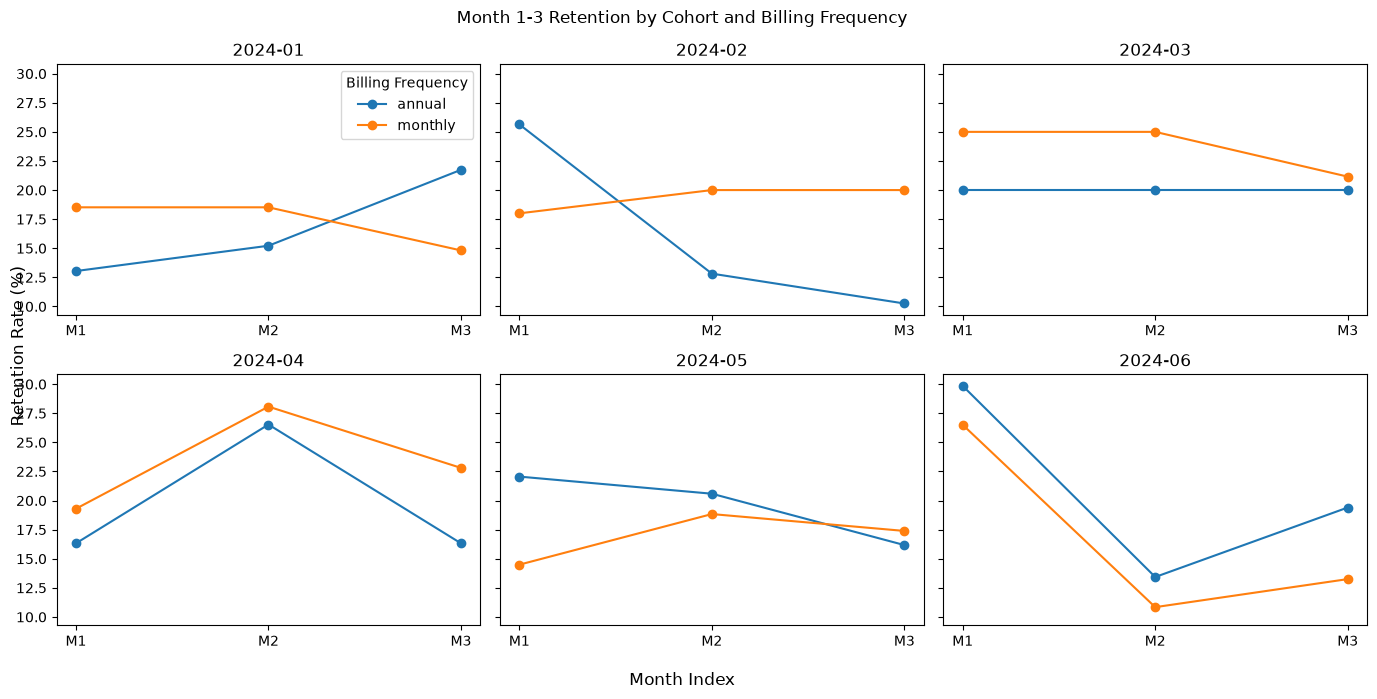

              monthly  annual  차이(monthly-annual, %p) 더 낮은 결제 주기
cohort_month                                                    
2024-01          18.5    13.0                     5.5     annual
2024-02          18.0    25.6                    -7.6    monthly
2024-03          25.0    20.0                     5.0     annual
2024-04          19.3    16.3                     3.0     annual
2024-05          14.5    22.1                    -7.6    monthly
2024-06          26.5    29.9                    -3.3    monthly
                                M1→M2(%p)  M2→M3(%p) M1→M2 패턴 M2→M3 패턴
cohort_month billing_frequency                                        
2024-01      annual                   2.2        6.5       회복       회복
             monthly                  0.0       -3.7       유지       감소
2024-02      annual                 -12.8       -2.6       감소       감소
             monthly                  2.0        0.0       회복       유지
2024-03      annual                   0.0        0.0  

In [4]:
# 과제 1 코드를 작성하세요.
cohort_base = (
    valid_usage[["subscription_id", "cohort_month"]]
    .drop_duplicates()
    .merge(subscriptions[["subscription_id", "billing_frequency"]], on="subscription_id")
)

selected_base = cohort_base[
    cohort_base["cohort_month"].between(pd.Period("2024-01", "M"), pd.Period("2024-06", "M"))
]

last_month = valid_usage["activity_month"].max()
cohorts = sorted(selected_base["cohort_month"].unique())
observable = pd.Series({c: (last_month - c).n for c in cohorts}, name="관찰 가능 개월 수")
print("데이터 마지막 월:", last_month)
print(observable.to_frame().assign(Month3_관찰가능=observable >= 3))

cohort_size = selected_base.groupby(["cohort_month", "billing_frequency"])["subscription_id"].nunique()

reuse_counts = (
    valid_usage[valid_usage["month_index"].between(1, 3)][["subscription_id", "month_index"]]
    .drop_duplicates()
    .merge(selected_base, on="subscription_id")
    .groupby(["cohort_month", "billing_frequency", "month_index"])["subscription_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=cohort_size.index, columns=[1, 2, 3], fill_value=0)
)

print(pd.concat([cohort_size.rename("최초 구독 수"), reuse_counts.add_prefix("Month ")], axis=1))

billing_retention = reuse_counts.div(cohort_size, axis=0)
months_observed = billing_retention.index.get_level_values("cohort_month").map(lambda c: (last_month - c).n)
for m in [1, 2, 3]:
    billing_retention.loc[months_observed < m, m] = float("nan")

print(
    billing_retention.add_prefix("Month ")
    .map(lambda x: f"{x:.1%}" if pd.notna(x) else "-")
)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, cohort in zip(axes.flat, cohorts):
    data = billing_retention.loc[cohort] * 100
    for billing in data.index:
        ax.plot([1, 2, 3], data.loc[billing], marker="o", label=billing)
    ax.set_title(str(cohort))
    ax.set_xticks([1, 2, 3], ["M1", "M2", "M3"])
axes[0, 0].legend(title="Billing Frequency")
fig.supxlabel("Month Index")
fig.supylabel("Retention Rate (%)")
fig.suptitle("Month 1-3 Retention by Cohort and Billing Frequency")
plt.tight_layout()
plt.show()

month1 = billing_retention[1].unstack()
month1_gap = pd.DataFrame({
    "monthly": month1["monthly"] * 100,
    "annual": month1["annual"] * 100,
    "차이(monthly-annual, %p)": (month1["monthly"] - month1["annual"]) * 100,
    "더 낮은 결제 주기": month1.idxmin(axis=1)
}).round(1)
print(month1_gap)

def pattern(x):
    if pd.isna(x):
        return "관찰 불가"
    return "감소" if x < -1 else ("회복" if x > 1 else "유지")

change = pd.DataFrame({
    "M1→M2(%p)": (billing_retention[2] - billing_retention[1]) * 100,
    "M2→M3(%p)": (billing_retention[3] - billing_retention[2]) * 100
}).round(1)
change["M1→M2 패턴"] = change["M1→M2(%p)"].apply(pattern)
change["M2→M3 패턴"] = change["M2→M3(%p)"].apply(pattern)
print(change)

target = (pd.Period("2024-02", "M"), "annual")
print("우선 점검 대상:", target[0], "/", target[1])
print("최초 구독 수:", cohort_size.loc[target])
print(billing_retention.loc[target].map(
    lambda x: f"{x:.1%}" if pd.notna(x) else "-"
))
print(change.loc[target])

### 과제 1 답변 작성란

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?
  - 1, 3, 4월은 annual / 2, 5, 6월은 monthly의 Month 1 리텐션이 더 낮았다. 차이는 각각 5.5%p, 7.6%p, 5.0%p, 3.0%p, 7.6%p, 3.3%p였다.

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?
  - 코호트별로 감소, 유지, 회복 패턴이 다르게 나타났다. 특히 2024-02 annual은 25.6% > 12.8% > 10.3%로 계속 감소했다.

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.
  - M1이 가장 낮은 조합은 2024-01 annual(13.0%)이지만 이후 15.2% > 21.7%로 회복했으므로 두 달 연속 감소한 2024-02 annual을 먼저 점검한다.
  - 가능한 원인 가설: 첫 사용 이후 지속적인 사용 가치를 충분히 느끼지 못했을 가능성이 있다.  
  - 개선 방향: 초기 사용 이후 재사용을 유도하는 기능 안내를 점검한다.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?
  - 결제 주기가 원인이라고 단정할 수는 없다. 기능 사용 빈도, 재방문 간격, 고객 규모 등을 추가로 확인해야 한다.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?
  - 구독별 첫 유효 기능 사용 월을 출발점으로 사용했다.

2. 월간 N개월 리텐션은 어떻게 계산했나요?
  - 첫 기능 사용 월로부터 N개월 뒤 기능을 다시 사용한 고유 구독 수를 해당 코호트의 최초 구독 수로 나누었다.

3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?
  - 같은 시기에 기능을 사용한 사용자 중에서도 어떤 특성의 그룹에서 유지(재방문율, 재구매율)이 낮은지 구체적으로 확인할 수 있다.

4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?
  - Basic, 18.8% 정도로 가장 낮았다.

5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?
  - 리텐션 표는 어느 그룹이 낮은지는 보여 주지만 요금제, 기능 경험, 고객 특성 중 무엇이 원인인지는 직접적으로 알려 주지는 않음.